In [108]:
using Pkg
Pkg.activate("..")
using MLDatasets, DataFrames, CSV, LinearAlgebra, MLDataUtils, Statistics, Plots, Random
housing = select(CSV.read("housing.csv", DataFrame), Not(:ocean_proximity))

  Activating project at `~/Documents/Classwork/Spring2026/MultiLinear`


Row,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
,Float64,Float64,Float64,Float64,Float64?,Float64,Float64,Float64,Float64
1,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
2,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
3,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
4,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
5,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
6,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0
7,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0
8,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.12,241400.0
9,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0


*Question 3*


In [80]:
"""
estimate values using kernel regression: 
X: The design matrix 
x: the points where we wish to predict 
y: the response variables
h: the smoothing parameter for the kernel function
note: this uses a gaussian kernel
"""
function m(X_train::AbstractVecOrMat, x_test::AbstractVecOrMat, y::AbstractVector, h::AbstractFloat, kernel::Function)
    
    norms = kernel(x_test, X_train, h)
    #display(norms)
    multiplied_value = norms * y
    valueSums = sum(norms, dims = 2)
    #display(valueSums)
    return multiplied_value./valueSums
    
end
"""
returns the kernel value based on a gaussian norm
x: the points to be estimated
X: the design matrix

return: a vector of size n (for n samples in x)
"""
function gaussianKernel(train::AbstractVecOrMat, test::AbstractVecOrMat, h::AbstractFloat)
    returnValue = zeros(size(train,1), size(test,1))
    train = train'
    test = test'
    for i in 1:size(test, 2)
        col = test[:,i]
        d2 = exp.(-norm.(eachcol(train .- col)).^2/(2h^2))
        returnValue[:, i] = d2
    end
    return returnValue
end
"""
return the MSE based on a ground truth and estimates
"""
function MSE(Y_est::AbstractVector, Y::AbstractVector)
    
    mean.(norm(Y_est-Y).^2)

end
(train, test) = splitobs(dropmissing!(housing), at = .8)
y_train = train[:,"median_house_value"]
X_train = Matrix(select(train, Not(:median_house_value)))
y_test =  test[:,"median_house_value"]
X_test = Matrix(select(test, Not(:median_house_value)))
h= [0.025, 0.05, 0.1, 0.2, 0.4, 0.8]

training_means = mean(X_train, dims = 1)
training_sd = std(X_train, dims =1)
X_test = (X_test .- training_means) ./ training_sd
X_train = (X_train.- training_means) ./training_sd


16346×8 Matrix{Float64}:
 -1.61094   1.25762   0.917139  …  -0.959685   -0.959575    2.41825
 -1.60574   1.24804  -0.645653      0.828878    1.61087     2.40553
 -1.61614   1.24325   1.77667      -0.809992   -0.830037    1.8475
 -1.62134   1.24325   1.77667      -0.756654   -0.723358    0.984643
 -1.62134   1.24325   1.77667      -0.750632   -0.62176     0.0241819
 -1.62134   1.24325   1.77667   …  -0.881397   -0.789397    0.126059
 -1.62134   1.23846   1.77667      -0.295533    0.0259311  -0.075825
 -1.62134   1.23846   1.77667      -0.241334    0.363746   -0.363979
 -1.62654   1.23846   0.995279     -0.19918     0.231668   -0.919656
 -1.62134   1.23846   1.77667       0.0976236   0.533924   -0.0586672
  ⋮                             ⋱   ⋮                      
 -0.971372  1.21929  -1.27077       0.697252    0.666002   -0.101695
 -0.960972  1.2145   -0.723793     -0.181113   -0.0578877  -0.542666
 -0.955772  1.23846  -0.098676     -0.177672   -0.256005   -0.490658
 -0.950573  1.20491 

In [121]:
estimates = m.(Ref(X_train[:,8]),Ref(X_test[:,8]), Ref(y_train), h, Ref(gaussianKernel))
meanSquredErrors = zeros(6)
for i in 1:6
    meanSquredErrors[i] = MSE(vec(estimates[i]), y_test)
end
display(meanSquredErrors)


6-element Vector{Float64}:
 2.671508993193919e13
 2.6640252063011715e13
 2.662581011249897e13
 2.6881063206355453e13
 2.8217690454354473e13
 3.4113053392463062e13

*Part A*

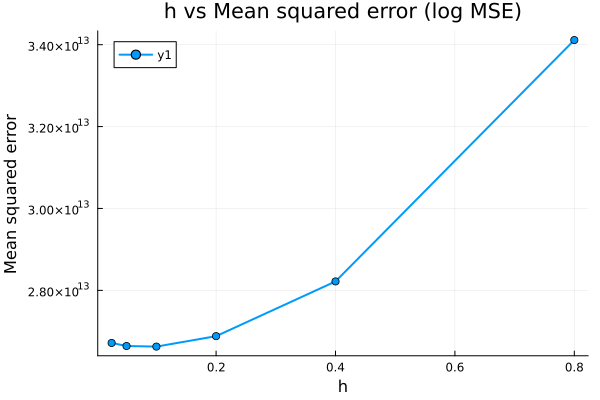

In [ ]:
X = [0.025, 0.05, 0.1, 0.2, 0.4, 0.8]   # example X
Y = meanSquredErrors            # same length as X
plot!(X, Y, seriestype=:scatter, label="points")
plot!(X, Y, seriestype=:line, label="line")
plot(X, Y, marker=:circle, lw=2, xlabel="h", ylabel="Mean squared error", title="h vs Mean squared error")

Though it's hard to see, I found h = .01 to be optimal and minimize the MSE.

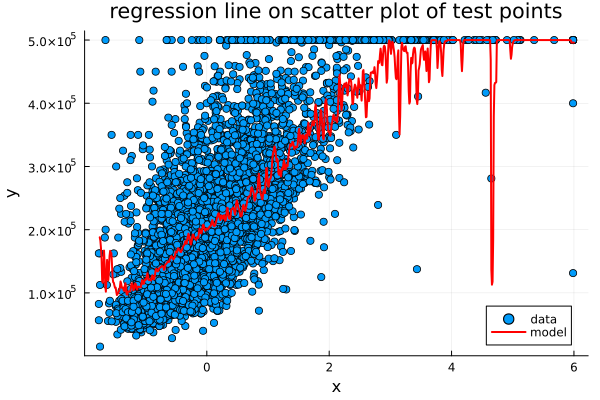

In [120]:
x_hat = -1.75:.01:6
y_hat =  m(X_train[:,8], x_hat, y_train, .01, gaussianKernel)

plot(X_test[:,8], y_test, seriestype=:scatter, marker=:circle, label="data", xlabel="x", ylabel="y")
plot!(x_hat, y_hat, seriestype=:line, lw=2, color=:red, label="model", title = "regression line on scatter plot of test points")

Here we can see the regression line performs better near the median values, but has higher variance near the extremely high x values (high incomes). This is what we expect, as kernel regression methods struggle in the extreme values where data points are less dense

*part b*

In [90]:
estimates = m.(Ref(X_train),Ref(X_test), Ref(y_train), h, Ref(gaussianKernel))

6-element Vector{Matrix{Float64}}:
 [174872.4496738823; 90600.0; … ; 103797.8847234392; 111799.99999999984;;]
 [166729.57624328235; 90600.00002277727; … ; 100621.062432744; 111792.7077020478;;]
 [146109.53443876552; 90710.33693070612; … ; 88791.71803899246; 108896.66197421445;;]
 [143592.3935826542; 114398.98465011436; … ; 96281.47646840314; 111704.4247634964;;]
 [148734.21282133006; 143160.165672592; … ; 103872.83512155827; 116716.55395017397;;]
 [147580.36551680136; 158445.4989754913; … ; 118177.08100236315; 127737.91622769661;;]

Because the scales of each of parameters are different (for example, the latitude don't have a big range, but household income does), I've decided the to normalize the columns. This way h behaves more consistently for different parameters

In [92]:
meanSquredErrors = zeros(6)
for i in 1:6
    meanSquredErrors[i] = MSE(vec(estimates[i]), y_test)
end
display(meanSquredErrors)
display(h)

6-element Vector{Float64}:
 NaN
 NaN
   3.1091503945937418e13
   2.484986965722855e13
   2.3482479025507047e13
   3.223620235196351e13

6-element Vector{Float64}:
 0.025
 0.05
 0.1
 0.2
 0.4
 0.8

Here we can see .4 is the value $\in h$ that minimizes the MSE. This makes sense, because when we increase the number of dimensions, the "volume" of the space we search incrases as well, so the density of points around each $x_0$ decreases. This means we need to increase h so points further away are still weighed enough for our regression. 
Our MSE is also improved with d = 8 (the full model), from an MSE of 2.6626e13 to 2.348e13. However, whether or not this is a statistically significant improvement, I'm not sure.

*part C, n = 500*

In [122]:
full = hcat(X_train, y_train)
perm = randperm(size(full,1))[1:500]
reduced = full[perm,:]
X_train_reduce = reduced[:,1:8]
y_train_reduce = reduced[:,9]

#for d = 1
estimates = m.(Ref(X_train_reduce[:,8]),Ref(X_test[:,8]), Ref(y_train_reduce), h, Ref(gaussianKernel))
meanSquredErrors = zeros(6)
for i in 1:6
    meanSquredErrors[i] = MSE(vec(estimates[i]), y_test)
end
display(meanSquredErrors)
display(h)

estimates = m.(Ref(X_train_reduce),Ref(X_test), Ref(y_train_reduce), h, Ref(gaussianKernel))
meanSquredErrors = zeros(6)
for i in 1:6
    meanSquredErrors[i] = MSE(vec(estimates[i]), y_test)
end
display(meanSquredErrors)
display(h)

6-element Vector{Float64}:
 3.061256234596914e13
 2.8646227597146344e13
 2.7600212387361938e13
 2.7164855864415234e13
 2.8042420642286496e13
 3.4282990118689477e13

6-element Vector{Float64}:
 0.025
 0.05
 0.1
 0.2
 0.4
 0.8

6-element Vector{Float64}:
 NaN
 NaN
 NaN
   3.9809740941446875e13
   3.3124471195524062e13
   3.6001675466257336e13

6-element Vector{Float64}:
 0.025
 0.05
 0.1
 0.2
 0.4
 0.8

Here we can see that with the reduced training set, when d = 1 (estimating house price based on household income) the ideal h is .2 (for the full dataset, h =.1), and the MSE went from 2.6626e13 for the full dataset to 2.7165e13 for n = 500 (not sure if the increase is statistically significant). However, when d = 8, the ideal h is still .4, and the MSE went from 2.3482e13 to 3.3124e13 which seems significant. When working on the reduced dataset, the d=8 performs even worse (far worse) than when d=1.
 

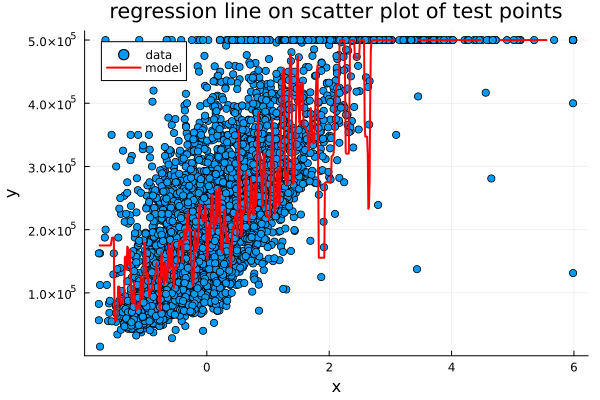

In [123]:
x_hat = -1.75:.01:6
y_hat =  m(X_train_reduce[:,8], x_hat, y_train_reduce, .01, gaussianKernel)

plot(X_test[:,8], y_test, seriestype=:scatter, marker=:circle, label="data", xlabel="x", ylabel="y")
plot!(x_hat, y_hat, seriestype=:line, lw=2, color=:red, label="model", title = "regression line on scatter plot of test points")

here, we can also see that the kernel regression line is much more "bumpy" as well, as there aren't as many points close by in the 500 set, as compared to the full set of data

**part D**

*i* as d goes from 1 to 8, largers values of h tends to lower MSE. This, again is due to the fact that as the dimensions go, the points around any given $x_0$ tends to get much less dense, so it's better weigh points far way a bit higher.

*ii* using all 8 predictors for n = 500 seemed to have harmed the model quite a bit. This is again due to the density issues. as we increase d, the points around $x_0$ are less dense, and we have fewer points to work with to begin with. 

Overall, increasing d can provide some moderate benefit to improving MSE, however, it comes with a few tradeoffs: if we increase d without increasing h as well, our models variance can increase dramatically (as it will estimate $y_0$ based on only a few points close to $x_0$, rather than many points in lower dimensional space). In order to ensure that we can utilize a higher d, we need to ensure we enough data points to begin with, otherwise the combined issues of lower numbers of datapoints, and lower density in higher dimensions can increase a models MSE dramatically (as we saw in part c). While it may seem counterintuitive that more information could hurt our predictions, the curse of dimensionality shows that high model complexity can ruin a models results.

Also, selecting h correctly can greatly impact our models performance. Too small for h, and the variance of the model goes up (again, because $y_0$ is being estimated on only a few points near $x_0$), but an h too high can increase the models bias by quite a bit (as points far away from $x_0$ may have too much input in estimating $y_0$)